In [1]:
import os
os.environ['KAGGLE_USERNAME'] = 'pranavraj5698'
os.environ['KAGGLE_KEY'] = 'KGAT_56248011e8dbf24f925e73c72eda29c4'

In [2]:
!pip install kaggle

In [3]:
!kaggle datasets download -d 'miadul/credit-card-fraud-detection-dataset'

Dataset URL: https://www.kaggle.com/datasets/miadul/credit-card-fraud-detection-dataset
License(s): apache-2.0
100% 111k/111k [00:00<00:00, 71.0MB/s]



In [4]:
!unzip credit-card-fraud-detection-dataset.zip

Archive:  credit-card-fraud-detection-dataset.zip
  inflating: credit_card_fraud_10k.csv  


In [5]:
import pandas as pd
import numpy as np

In [6]:
df = pd.read_csv('/content/credit_card_fraud_10k.csv')

In [7]:
df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [8]:
df.tail()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
9995,9996,350.91,22,Food,0,0,99,4,37,0
9996,9997,410.04,5,Clothing,0,0,70,3,25,0
9997,9998,527.75,21,Electronics,0,0,44,2,45,0
9998,9999,91.20,2,Electronics,0,0,38,0,37,0
9999,10000,44.06,2,Clothing,0,0,38,0,66,0


In [9]:
df.dtypes

,0
transaction_id,int64
amount,float64
transaction_hour,int64
merchant_category,object
foreign_transaction,int64
location_mismatch,int64
device_trust_score,int64
velocity_last_24h,int64
cardholder_age,int64
is_fraud,int64


In [10]:
df.describe()

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,175.949849,11.593300,0.097800,0.085700,61.798900,2.008900,43.468700,0.015100
std,2886.89568,175.392827,6.922708,0.297059,0.279935,21.487053,1.432559,14.979147,0.121957
min,1.00000,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,18.000000,0.000000
25%,2500.75000,50.905000,6.000000,0.000000,0.000000,43.000000,1.000000,30.000000,0.000000
50%,5000.50000,122.095000,12.000000,0.000000,0.000000,62.000000,2.000000,44.000000,0.000000
75%,7500.25000,242.480000,18.000000,0.000000,0.000000,80.000000,3.000000,56.000000,0.000000
max,10000.00000,1471.040000,23.000000,1.000000,1.000000,99.000000,9.000000,69.000000,1.000000


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


In [12]:
df.shape

(10000, 10)

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.isnull().sum()

,0
transaction_id,0
amount,0
transaction_hour,0
merchant_category,0
foreign_transaction,0
location_mismatch,0
device_trust_score,0
velocity_last_24h,0
cardholder_age,0
is_fraud,0


In [16]:
df['is_fraud'].value_counts()

,count
is_fraud,
0,9849
1,151


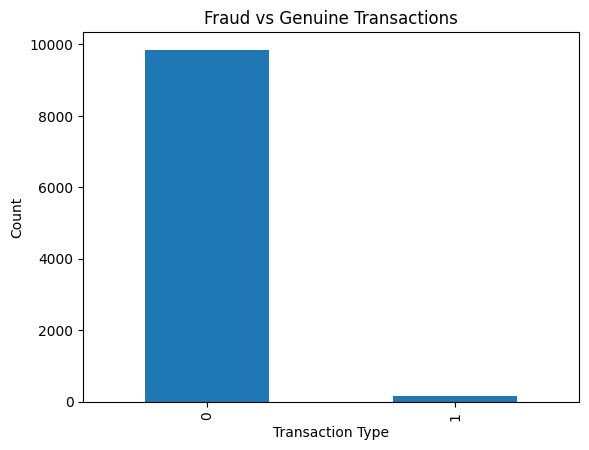

In [17]:
import matplotlib.pyplot as plt
fraud_count = df['is_fraud'].value_counts()
fraud_count.plot(kind='bar')

plt.title("Fraud vs Genuine Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.show()

In [19]:
corr = df.corr(numeric_only=True)

In [20]:
corr

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
transaction_id,1.000000,-0.017676,-0.020081,-0.003746,0.003599,0.012292,-0.013903,0.005412,-0.010155
amount,-0.017676,1.000000,-0.007369,0.004094,0.004232,0.009698,-0.001133,0.012735,0.028404
transaction_hour,-0.020081,-0.007369,1.000000,-0.000255,0.004776,0.004054,-0.003709,0.012198,-0.138665
foreign_transaction,-0.003746,0.004094,-0.000255,1.000000,0.001426,0.012780,-0.007686,0.005408,0.185597
location_mismatch,0.003599,0.004232,0.004776,0.001426,1.000000,0.002217,-0.005892,0.010049,0.173009
device_trust_score,0.012292,0.009698,0.004054,0.012780,0.002217,1.000000,-0.000095,0.013717,-0.137913
velocity_last_24h,-0.013903,-0.001133,-0.003709,-0.007686,-0.005892,-0.000095,1.000000,-0.003970,0.103413
cardholder_age,0.005412,0.012735,0.012198,0.005408,0.010049,0.013717,-0.003970,1.000000,-0.000590
is_fraud,-0.010155,0.028404,-0.138665,0.185597,0.173009,-0.137913,0.103413,-0.000590,1.000000


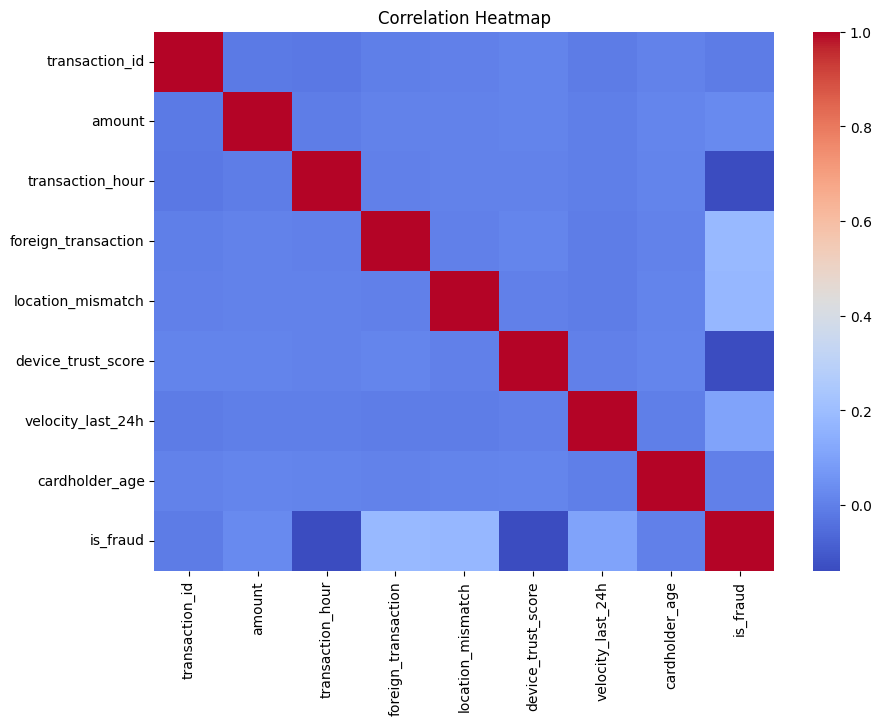

In [21]:
import seaborn as sns
plt.figure(figsize=(10,7))
sns.heatmap(corr,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [23]:
df1 = df.copy()

In [24]:
df1

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0
...,...,...,...,...,...,...,...,...,...,...
9995,9996,350.91,22,Food,0,0,99,4,37,0
9996,9997,410.04,5,Clothing,0,0,70,3,25,0
9997,9998,527.75,21,Electronics,0,0,44,2,45,0
9998,9999,91.20,2,Electronics,0,0,38,0,37,0


In [25]:
df = pd.get_dummies(df, columns=["merchant_category"], drop_first=True)

In [27]:
X = df.drop(["is_fraud", "transaction_id"], axis=1)
y = df["is_fraud"]

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify = y)

In [31]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

In [32]:
print(X_train.shape)
print(X_test.shape)

(15758, 11)
(2000, 11)


In [33]:
from sklearn.linear_model import LogisticRegression

In [34]:
lg_model = LogisticRegression(max_iter=1000, class_weight='balanced')

In [35]:
lg_model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [36]:
y_pred_lg = lg_model.predict(X_test)

In [37]:
print(accuracy_score(y_test, y_pred_lg))

0.925


In [40]:
from sklearn.ensemble import RandomForestClassifier

In [41]:
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)

In [42]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [43]:
y_pred_rf = rf_model.predict(X_test)

In [67]:
print(accuracy_score(y_test, y_pred_rf))


0.9825


In [45]:
!pip install xgboost
import xgboost as xgb

In [47]:
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42)

In [48]:
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

In [49]:
y_pred_xgb = xgb_model.predict(X_test)

In [66]:
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))


Accuracy: 0.988


In [54]:
import shap

In [55]:
print(shap.__version__)

0.52.0


In [56]:
xgb_model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

In [58]:
X_sample = X_test.sample(1000, random_state=42)

In [59]:
explainer = shap.Explainer(xgb_model)

In [60]:
shap_values = explainer(X_sample)

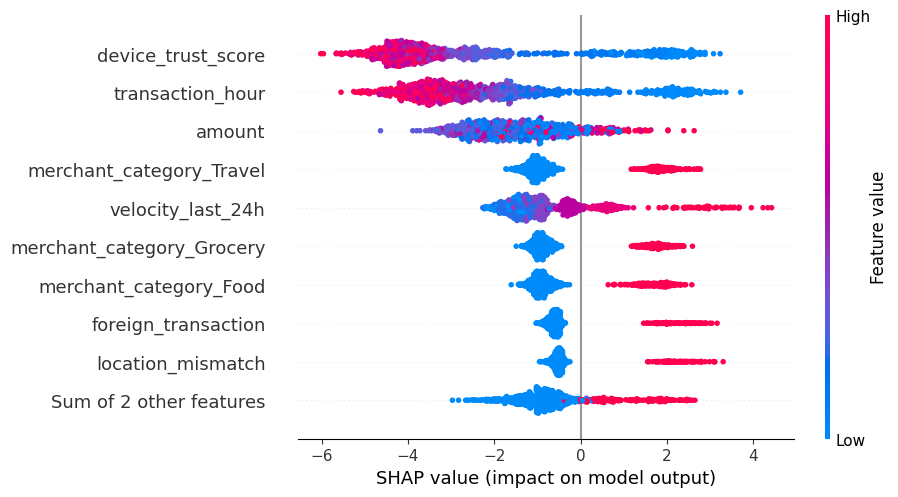

In [61]:
shap.plots.beeswarm(shap_values)

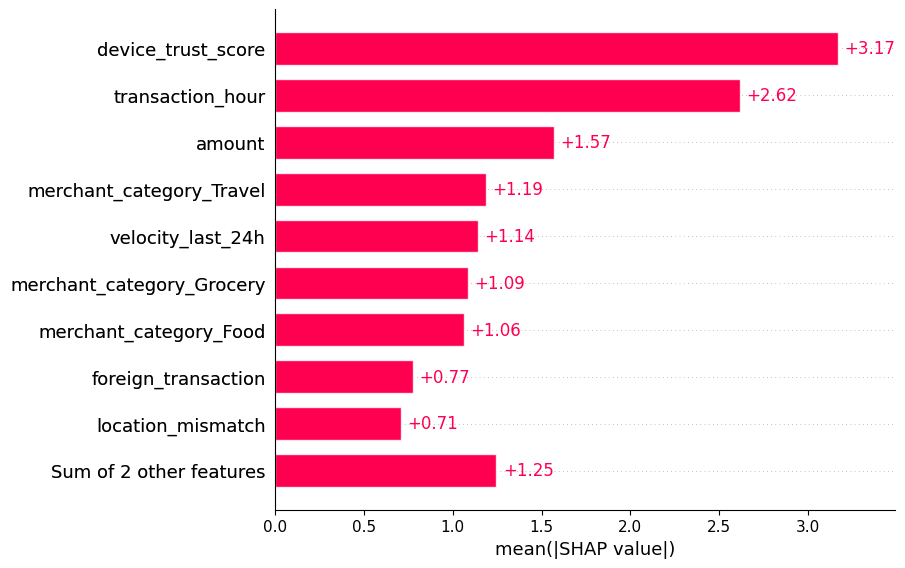

In [62]:
shap.plots.bar(shap_values)

In [63]:
import pickle

In [64]:
with open('xgb_model.pkl', 'wb') as file:
  pickle.dump(xgb_model, file)

In [65]:
from google.colab import files
files.download('xgb_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
with open("feature_columns.pkl", "wb") as file:
    pickle.dump(X_train.columns.tolist(), file)

In [ ]:
from google.colab import files
files.download('feature_columns.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>